In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mpc

In [2]:
from taylorDiagram import TaylorDiagram

Load Data

In [3]:
STNS = np.loadtxt("../DATA/Stations.txt",dtype='U2')
VNS = np.loadtxt("../DATA/Products.txt",dtype='<U10')

STN_DATA = xr.open_dataarray("../DATA/STN_DATA.nc")
STN_CC = xr.open_dataarray("../DATA/STN_CC.nc")
STN_RMSE = xr.open_dataarray("../DATA/STN_RMSE.nc")

Separate OBS from EST
- Average across all stations

In [4]:
O = STN_DATA.loc[dict(Product="PM")]
sigma_O = O.std(dim=["datetime"])
sigma_Om = sigma_O.mean(dim="Station")

R = STN_DATA.drop_sel(Product=["PM", "TH"])
sigma_R = R.std(dim=["datetime"])
sigma_Rm = sigma_R.mean(dim="Station")

R_CC = STN_CC.drop_sel(Product=["PM", "TH"])
R_CCm = R_CC.mean(dim="Station")

R_RMSE = STN_RMSE.drop_sel(Product=["PM", "TH"])
R_RMSEm = R_RMSE.mean(dim="Station")

Generate index to sort R products by RMSE before plotting

In [5]:
sri = np.argsort(R_RMSEm)

In [6]:
R_RMSEm.values[sri]

array([3.0811338 , 3.16487679, 3.67357503, 3.84850717, 3.93822748,
       4.15862404, 5.02938502, 5.34436306, 6.75199918, 7.19815216])

In [7]:
R_RMSEm.Product.values

array(['AQUA', 'ERA5', 'GLDAS', 'GLEAM', 'JRA', 'LSA', 'MERRA', 'SSEBop',
       'TERRA', 'WaPOR'], dtype='<U6')

Create markers = "^" and "v" for satellites (need to tell aqua and terra apart), "o" for reanalysis.

In [8]:
i_markers = (["v", "o", "o", "^", "o", "v", "o", "v", "^", "v"])

Create a Taylor plot.

C:\Users\Haneen.Muhammad\AppData\Local\Temp\ipykernel_13260\3326730254.py:14: MatplotlibDeprecationWarning: Passing `apply_theta_transforms=True` (the default) is deprecated since Matplotlib 3.9. Support for this will be removed in Matplotlib in 3.11. To prevent this warning, set `apply_theta_transforms=False`, and make sure to shift theta values before being passed to this transform.
  plt.clabel(contours, inline=1, fontsize=10, fmt='%.2f')


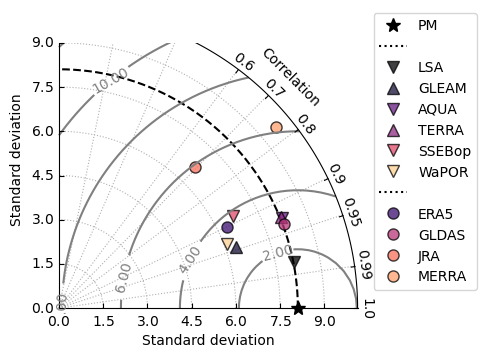

In [9]:
i_colors = plt.matplotlib.cm.magma(np.linspace(0, 1, len(sri)+1))
fig = plt.figure(figsize=(5, 3.5))
# Taylor diagram
dia = TaylorDiagram(sigma_Om.values, fig=fig, extend=False, label="PM", srange=(0, 1.25))
for i in range(len(sri)):
    dia.add_sample(sigma_Rm[sri[i]].values, R_CCm[sri[i]].values,
                       marker=i_markers[sri[i].values], ms=8, ls='',
                       mfc=i_colors[i], mec='k', alpha=0.75,
                       label=R_CCm.Product.values[sri[i]])
# Add grid
dia.add_grid(ls=':')
# Add RMS contours, and label them
contours = dia.add_contours(levels=6, colors='0.5')
plt.clabel(contours, inline=1, fontsize=10, fmt='%.2f')

ax = plt.gca()

handles,labels = ax.get_legend_handles_labels()

qwe = plt.Line2D(np.array([0, 1]), np.array([0, 1]), linestyle=":", color='k')

handles = [handles[0], qwe, handles[1], handles[2], handles[4], handles[5], handles[7], handles[10], qwe, handles[3], handles[6], handles[8], handles[9]]

labels = [labels[0], "", labels[1], labels[2], labels[4], labels[5], labels[7], labels[10], "", labels[3], labels[6], labels[8], labels[9]]

ax.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.6))

plt.tight_layout()

ax.set_ylim(-0.2, 9)

plt.savefig("ET4I_Taylor_Original.png", dpi=300)